# Диагностика источников ошибки локализации

Этот notebook читает только сохранённые артефакты восьми зафиксированных случаев. Он не синтезирует аудио и не запускает трекер. Варианты `original`, `ideal_bearing` и `zero_bias` являются взаимодействующими диагностическими вмешательствами, а не аддитивным разложением ошибки.

In [1]:
from pathlib import Path
import csv, gzip, hashlib, json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
RESULTS = Path(os.environ.get("LOCALIZATION_ERROR_ATTRIBUTION_RESULTS", ROOT / "results" / "localization_error_attribution"))
FIGURES = RESULTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
manifest = json.loads((RESULTS / "diagnostic_manifest.json").read_text())
study = json.loads((RESULTS / "study_summary.json").read_text())
variants = pd.read_csv(RESULTS / "variant_summary.csv")
bearings = pd.read_csv(RESULTS / "bearing_station_summary.csv")
geometry = pd.read_csv(RESULTS / "geometry_summary.csv")
assert manifest["case_count"] == study["case_count"] == 8
assert study["audio_restoration_count"] == 8
assert study["method_variant_count"] == len(variants) == 48
assert study["all_original_reproductions_passed"]
variants.head()

,accepted_update_count,availability_fraction,batch_optimization_budget,batch_optimization_count,batch_optimization_runtime_s,diagnostic_id,diagnostic_variant,distance_m,estimator_variant,event_count,...,rejected_update_count,replicate,reset_count,snr_db,source_run_id,tracker_runtime_s,trajectory,update_rejection_reasons,valid_measurement_count,valid_publication_count
0,134,0.94,128,2,0.073600,attr-c1c839b03b9daf2a307bf1a6,original,200,all_6_equal_gcc_wls,150,...,6,0,0,10.0,range-272dde7dd08ac45c22d609f9,1.088369,single_turn,"{""emission_outside_history"":6}",150,141
1,134,0.94,128,2,0.074419,attr-c1c839b03b9daf2a307bf1a6,ideal_bearing,200,all_6_equal_gcc_wls,150,...,6,0,0,10.0,range-272dde7dd08ac45c22d609f9,1.258340,single_turn,"{""emission_outside_history"":6}",150,141
2,134,0.94,128,2,0.073129,attr-c1c839b03b9daf2a307bf1a6,zero_bias,200,all_6_equal_gcc_wls,150,...,6,0,0,10.0,range-272dde7dd08ac45c22d609f9,1.337850,single_turn,"{""emission_outside_history"":6}",150,141
3,134,0.94,128,2,0.077823,attr-c1c839b03b9daf2a307bf1a6,original,200,equal_weight_srp_phat,150,...,6,0,0,10.0,range-272dde7dd08ac45c22d609f9,1.234459,single_turn,"{""emission_outside_history"":6}",150,141
4,134,0.94,128,2,0.071858,attr-c1c839b03b9daf2a307bf1a6,ideal_bearing,200,equal_weight_srp_phat,150,...,6,0,0,10.0,range-272dde7dd08ac45c22d609f9,1.116874,single_turn,"{""emission_outside_history"":6}",150,141


In [2]:
case_dirs = {int(p.name[:3]): p for p in (RESULTS / "cases").iterdir() if p.is_dir()}
phase_rows, update_rows, initialization_rows = [], [], []
for case in manifest["cases"]:
    index = int(case["index"])
    directory = case_dirs[index]
    for method in manifest["methods"]:
        for variant in manifest["variants"]:
            track = pd.read_csv(directory / f"tracking_{method}_{variant}.csv.gz")
            valid = track[track["valid"]]
            for phase, group in valid.groupby("publication_motion_phase_evaluator_only"):
                phase_rows.append({
                    "index": index, "source_run_id": case["source_run_id"], "trajectory": case["trajectory"],
                    "experiment": case["experiment"], "distance_m": case["distance_m"],
                    "estimator_variant": method, "diagnostic_variant": variant, "phase": phase,
                    "valid_publication_count": len(group),
                    "position_rmse_m": float(np.sqrt(np.mean(group["position_error_m"]**2))),
                    "position_p95_m": float(np.percentile(group["position_error_m"], 95)),
                    "radial_rmse_m": float(np.sqrt(np.mean(group["radial_position_error_m"]**2))),
                    "transverse_rmse_m": float(np.sqrt(np.mean(group["transverse_position_error_m"]**2))),
                    "position_coverage_fraction": float(group["valid_and_position_covered"].mean()),
                })
            updates = pd.read_csv(directory / f"updates_{method}_{variant}.csv.gz")
            for column in ("pre_update_nis", "failure_reason"):
                if column not in updates:
                    updates[column] = np.nan
            applied_mask = updates["update_applied"].astype(str).eq("True")
            accepted = updates.loc[applied_mask]
            rejected = updates.loc[~applied_mask]
            update_rows.append({
                "index": index, "source_run_id": case["source_run_id"], "estimator_variant": method,
                "diagnostic_variant": variant, "accepted_count": len(accepted), "rejected_count": len(rejected),
                "accepted_nis_median": accepted["pre_update_nis"].median(),
                "accepted_nis_max": accepted["pre_update_nis"].max(),
                "rejected_finite_nis_median": rejected["pre_update_nis"].median(),
                "rejection_reasons_json": json.dumps(rejected["failure_reason"].value_counts().to_dict(), sort_keys=True),
            })
            fits = pd.read_csv(directory / f"batch_fits_{method}_{variant}.csv.gz")
            hit = fits[fits["reason"] == "computational_budget_exceeded_before_fit"]
            initialization_rows.append({
                "index": index, "source_run_id": case["source_run_id"], "estimator_variant": method,
                "diagnostic_variant": variant, "attempted_fit_count": int(pd.to_numeric(fits["fit_count_after_attempt"], errors="coerce").max()) if len(fits) and "fit_count_after_attempt" in fits else 0,
                "budget_exhaustion_time_s": float(hit.iloc[0]["processing_time_s"]) if len(hit) else np.nan,
                "batch_reason_counts_json": json.dumps(fits["reason"].value_counts().to_dict(), sort_keys=True) if len(fits) else "{}",
            })
phase = pd.DataFrame(phase_rows)
updates = pd.DataFrame(update_rows)
initialization = pd.DataFrame(initialization_rows)
phase.to_csv(RESULTS / "phase_summary.csv", index=False, lineterminator="\n")
updates.to_csv(RESULTS / "update_summary.csv", index=False, lineterminator="\n")
initialization.to_csv(RESULTS / "initialization_summary.csv", index=False, lineterminator="\n")
geometry_case = geometry.groupby(["index", "trajectory", "distance_m"], as_index=False).agg(
    rank_min=("rank", "min"), condition_median=("condition_number", "median"),
    condition_max=("condition_number", "max"), weak_radial_alignment_median=("weak_direction_radial_alignment_abs", "median"),
    radial_sigma_median_m=("radial_sigma_m", "median"), transverse_sigma_median_m=("transverse_sigma_rss_m", "median"),
    maximum_axis_p95_scale_median_m=("maximum_axis_p95_scale_m", "median"))
geometry_case.to_csv(RESULTS / "geometry_case_summary.csv", index=False, lineterminator="\n")
phase.shape, updates.shape, initialization.shape, geometry_case.shape

((250, 14), (48, 10), (48, 7), (8, 10))

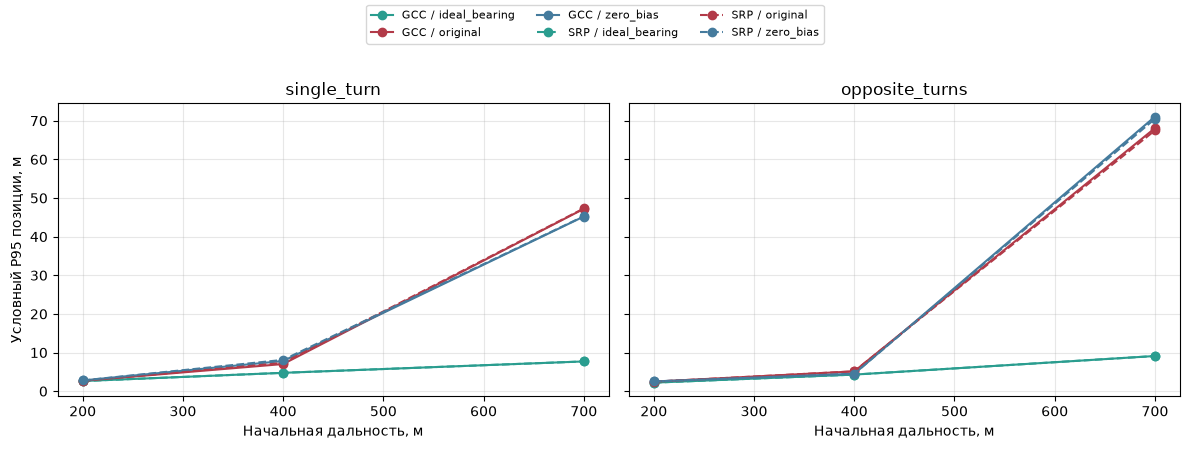

In [3]:
labels = {"all_6_equal_gcc_wls": "GCC", "equal_weight_srp_phat": "SRP"}
colors = {"original":"#b23a48", "ideal_bearing":"#2a9d8f", "zero_bias":"#457b9d"}
geo = variants[variants["experiment"] == "geometry_control"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, trajectory in zip(axes, ["single_turn", "opposite_turns"]):
    part = geo[geo["trajectory"] == trajectory]
    for (method, variant), group in part.groupby(["estimator_variant", "diagnostic_variant"]):
        ax.plot(group["distance_m"], group["position_p95_m_conditional"], marker="o",
                linestyle="-" if method.startswith("all") else "--", color=colors[variant],
                label=f"{labels[method]} / {variant}")
    ax.set_title(trajectory); ax.set_xlabel("Начальная дальность, м"); ax.grid(alpha=.3)
axes[0].set_ylabel("Условный P95 позиции, м")
handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, names, loc="upper center", ncol=3, fontsize=8)
fig.tight_layout(rect=(0,0,1,.86))
fig.savefig(FIGURES / "variant_p95_by_distance.png", dpi=160)
plt.show()

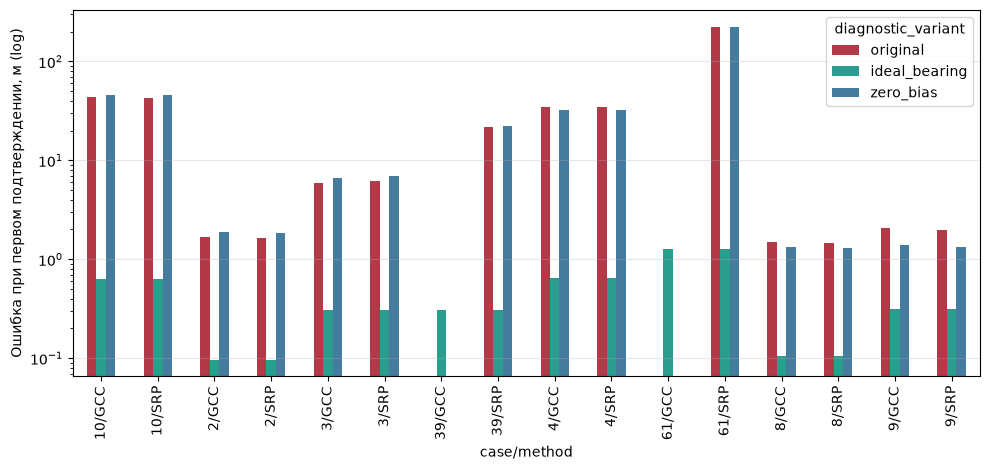

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.8))
first = variants[variants["first_confirmation_position_error_m"].notna()].copy()
first["label"] = first["index"].astype(str) + "/" + first["estimator_variant"].map(labels)
for variant, group in first.groupby("diagnostic_variant"):
    x = np.arange(len(group))
# aligned categorical plot
pivot = first.pivot(index="label", columns="diagnostic_variant", values="first_confirmation_position_error_m")
pivot = pivot.reindex(columns=["original", "ideal_bearing", "zero_bias"])
pivot.plot(kind="bar", ax=ax, color=[colors[c] for c in pivot.columns])
ax.set_yscale("log"); ax.set_ylabel("Ошибка при первом подтверждении, м (log)"); ax.set_xlabel("case/method")
ax.grid(axis="y", alpha=.3); fig.tight_layout(); fig.savefig(FIGURES / "first_confirmation_error.png", dpi=160)
plt.show()

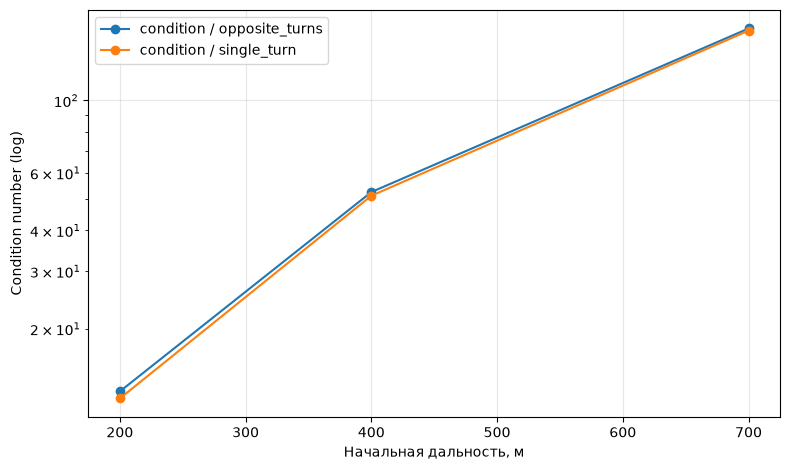

,index,trajectory,distance_m,rank_min,condition_median,condition_max,weak_radial_alignment_median,radial_sigma_median_m,transverse_sigma_median_m,maximum_axis_p95_scale_median_m
0,2,single_turn,200,3,12.238212,14.142494,0.999902,7.453786,3.081173,20.839181
1,3,single_turn,400,3,51.081237,55.124713,0.999994,29.488993,5.864699,82.436513
2,4,single_turn,700,3,163.650201,170.943688,0.999999,91.399618,10.120063,255.506305
3,8,opposite_turns,200,3,12.857310,15.172930,0.999959,7.815906,3.148378,21.851209
4,9,opposite_turns,400,3,52.422554,57.267199,0.999995,30.236787,5.935186,84.526932
5,10,opposite_turns,700,3,166.087091,174.754218,0.999999,92.726134,10.191098,259.214554
6,39,single_turn,400,3,51.081237,55.124713,0.999994,29.488993,5.864699,82.436513
7,61,single_turn,1000,3,341.685664,352.239781,1.000000,187.933158,14.389035,525.364134


In [5]:
fig, ax1 = plt.subplots(figsize=(8, 4.8))
for trajectory, group in geometry_case.groupby("trajectory"):
    base = group[group["index"].isin([2,3,4,8,9,10])]
    ax1.plot(base["distance_m"], base["condition_median"], marker="o", label=f"condition / {trajectory}")
ax1.set_yscale("log"); ax1.set_xlabel("Начальная дальность, м"); ax1.set_ylabel("Condition number (log)")
ax1.grid(alpha=.3); ax1.legend(); fig.tight_layout(); fig.savefig(FIGURES / "geometry_condition.png", dpi=160)
plt.show()
geometry_case

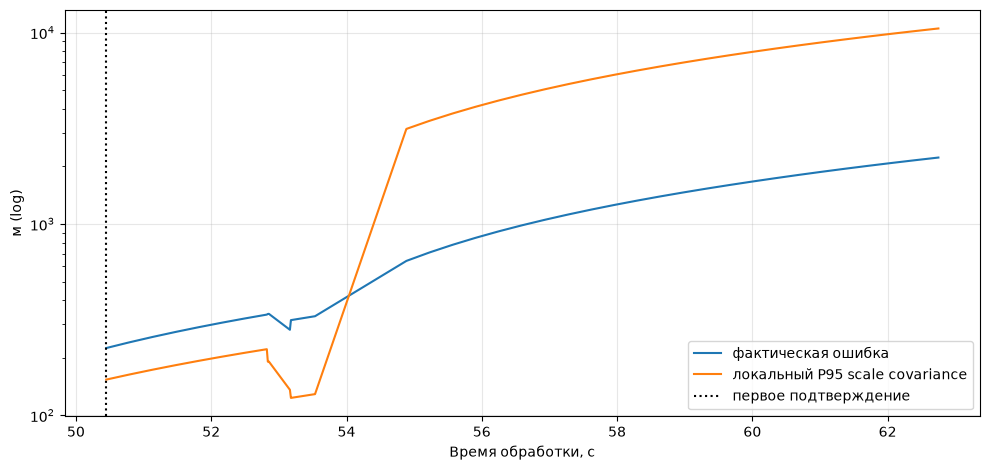

,processing_time_s,publication_motion_phase_evaluator_only,position_error_m,radial_position_error_m,transverse_position_error_m,position_nees
40,50.447646,straight,224.700399,-224.186287,15.191380,29.066627
41,50.462646,straight,225.400849,-224.885702,15.230359,29.060937
42,50.773979,straight,239.967973,-239.433381,16.008878,28.842406
43,50.788979,straight,240.670704,-240.135246,16.045293,28.827755
44,50.803979,straight,241.373486,-240.837166,16.081641,28.812792


In [6]:
case61 = case_dirs[61]
track = pd.read_csv(case61 / "tracking_equal_weight_srp_phat_original.csv.gz")
valid = track[track["valid"]]
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(valid["processing_time_s"], valid["position_error_m"], label="фактическая ошибка")
ax.plot(valid["processing_time_s"], valid["position_maximum_axis_p95_scale_m"], label="локальный P95 scale covariance")
ax.axvline(valid.iloc[0]["processing_time_s"], color="black", linestyle=":", label="первое подтверждение")
ax.set_yscale("log"); ax.set_xlabel("Время обработки, с"); ax.set_ylabel("м (log)"); ax.grid(alpha=.3); ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "case61_srp_error_time.png", dpi=160)
plt.show()
valid[["processing_time_s","publication_motion_phase_evaluator_only","position_error_m","radial_position_error_m","transverse_position_error_m","position_nees"]].head()

In [7]:
key = variants[(variants["index"].isin([4,10,39,61])) & (variants["diagnostic_variant"].isin(["original","ideal_bearing","zero_bias"]))]
key[["index","estimator_variant","diagnostic_variant","final_confirmed","first_confirmation_time_s_relative","first_confirmation_position_error_m","position_p95_m_conditional","accepted_update_count","rejected_update_count","batch_optimization_count"]].sort_values(["index","estimator_variant","diagnostic_variant"])

,index,estimator_variant,diagnostic_variant,final_confirmed,first_confirmation_time_s_relative,first_confirmation_position_error_m,position_p95_m_conditional,accepted_update_count,rejected_update_count,batch_optimization_count
13,4,all_6_equal_gcc_wls,ideal_bearing,True,1.055312,0.649389,7.707652,122,18,2
12,4,all_6_equal_gcc_wls,original,True,1.055312,34.439377,47.207768,122,18,2
14,4,all_6_equal_gcc_wls,zero_bias,True,1.055312,32.356179,45.213381,122,18,2
16,4,equal_weight_srp_phat,ideal_bearing,True,1.055312,0.649431,7.702769,122,18,2
15,4,equal_weight_srp_phat,original,True,1.055312,34.544162,47.296349,122,18,2
17,4,equal_weight_srp_phat,zero_bias,True,1.055312,32.443270,45.285158,122,18,2
31,10,all_6_equal_gcc_wls,ideal_bearing,True,1.055312,0.625977,9.108301,134,18,2
30,10,all_6_equal_gcc_wls,original,True,1.055312,43.228747,68.081569,132,20,2
32,10,all_6_equal_gcc_wls,zero_bias,True,1.055312,46.048519,71.067643,132,20,2
34,10,equal_weight_srp_phat,ideal_bearing,True,1.055312,0.626014,9.105602,134,18,2


In [8]:
diagnosis = pd.DataFrame([
    {"case":"geometry_control 200 m", "observation":"P95 original 2.46–2.70 m; ideal 2.22–2.63 m; median condition ≈12", "cause_or_hypothesis":"Geometry is still moderate; acoustic bearings add a smaller error component", "support":"original vs ideal; local static geometry benchmark"},
    {"case":"geometry_control 400 m", "observation":"P95 original 5.13–7.32 m; ideal 4.30–4.76 m; median condition ≈51–52", "cause_or_hypothesis":"Geometry and strict-CV tracking already limit accuracy; acoustic error is amplified", "support":"ideal remains nonzero while original is worse"},
    {"case":"geometry_control 700 m", "observation":"First-confirmation error 34–43 m original versus 0.63–0.65 m ideal; error is almost radial", "cause_or_hypothesis":"Confirmed: weak radial geometry amplifies small acoustic bearing errors during initialization", "support":"angular P95 ≈0.14°, condition ≈164–166, weak-axis radial alignment ≈1"},
    {"case":"fixed_background 400 m / GCC", "observation":"Original and zero-bias exhaust 128 fits at 47.701979 s; ideal confirms after 2 fits", "cause_or_hypothesis":"Confirmed: gross acoustic bearing errors prevent initialization; calibration bias is not the cause", "support":"GCC station angular P95 reaches 136.22°; ideal replay succeeds"},
    {"case":"fixed_background 400 m / SRP", "observation":"Confirms at 5.151 s with 21.58 m error, loses twice, final invalid; ideal confirms at 1.055 s", "cause_or_hypothesis":"Confirmed: acoustic errors produce a bad late initialization and subsequent update loss", "support":"original P95 73.25 m versus ideal 4.76 m; 14 NIS and 21 history rejections"},
    {"case":"fixed_background 1000 m / GCC", "observation":"Original and zero-bias exhaust 128 fits at 56.917979 s; ideal confirms after 2 fits", "cause_or_hypothesis":"Confirmed: acoustic corruption, amplified by very weak radial geometry, blocks initialization", "support":"condition ≈342; ideal P95 11.58 m"},
    {"case":"fixed_background 1000 m / SRP", "observation":"Already 224.70 m wrong at confirmation; grows to 2222.83 m; only 3 updates accepted", "cause_or_hypothesis":"Confirmed interaction: bad acoustic initialization plus radial ambiguity; the later error accumulates after confirmation", "support":"ideal first error 1.27 m; accepted NIS 0.77–7.65 at 280–339 m position error; 90 history and 6 NIS rejections"},
    {"case":"zero_bias intervention", "observation":"Does not rescue either GCC budget failure or the bad SRP tracks; changes at 700 m are mixed", "cause_or_hypothesis":"Confirmed: stored calibration bias is not the primary failure source", "support":"original versus zero-bias statuses/counts and P95"},
])
diagnosis.to_csv(RESULTS / "diagnosis_table.csv", index=False, lineterminator="\n")
derived = ["phase_summary.csv", "update_summary.csv", "initialization_summary.csv", "geometry_case_summary.csv", "diagnosis_table.csv"]
analysis_summary = {
    "schema_version": 1,
    "case_count": 8,
    "method_variant_count": 48,
    "audio_restoration_count": 8,
    "interpretation": "diagnostic known-case attribution; effects are interacting and non-additive",
    "priority_next_change": "observable-data-only robust pre-initialization bearing consistency/outlier gate before the bounded candidate search",
    "required_before_implementation": "freeze the gate on separate development cases and test it on held-out range-study streams; truth and position error must remain evaluator-only",
    "derived_tables": {name: hashlib.sha256((RESULTS / name).read_bytes()).hexdigest() for name in derived},
}
(RESULTS / "analysis_summary.json").write_text(json.dumps(analysis_summary, indent=2, sort_keys=True) + "\n")
diagnosis

,case,observation,cause_or_hypothesis,support
0,geometry_control 200 m,P95 original 2.46–2.70 m; ideal 2.22–2.63 m; m...,Geometry is still moderate; acoustic bearings ...,original vs ideal; local static geometry bench...
1,geometry_control 400 m,P95 original 5.13–7.32 m; ideal 4.30–4.76 m; m...,Geometry and strict-CV tracking already limit ...,ideal remains nonzero while original is worse
2,geometry_control 700 m,First-confirmation error 34–43 m original vers...,Confirmed: weak radial geometry amplifies smal...,"angular P95 ≈0.14°, condition ≈164–166, weak-a..."
3,fixed_background 400 m / GCC,Original and zero-bias exhaust 128 fits at 47....,Confirmed: gross acoustic bearing errors preve...,GCC station angular P95 reaches 136.22°; ideal...
4,fixed_background 400 m / SRP,"Confirms at 5.151 s with 21.58 m error, loses ...",Confirmed: acoustic errors produce a bad late ...,original P95 73.25 m versus ideal 4.76 m; 14 N...
5,fixed_background 1000 m / GCC,Original and zero-bias exhaust 128 fits at 56....,"Confirmed: acoustic corruption, amplified by v...",condition ≈342; ideal P95 11.58 m
6,fixed_background 1000 m / SRP,Already 224.70 m wrong at confirmation; grows ...,Confirmed interaction: bad acoustic initializa...,ideal first error 1.27 m; accepted NIS 0.77–7....
7,zero_bias intervention,Does not rescue either GCC budget failure or t...,Confirmed: stored calibration bias is not the ...,original versus zero-bias statuses/counts and P95
